# Sales Forecasting Using Linear Regression

## Task 1 - Machine Learning Project

### Objective
The objective of this project is to analyze historical sales data and forecast future sales using Linear Regression. The project includes data preprocessing, exploratory data analysis, model building, evaluation, and future sales prediction.

## 1. Importing Required Libraries

In [21]:
import pandas as pd
import numpy as np

## 2. Dataset Loading

In this step, the Superstore sales dataset is loaded into a pandas DataFrame for analysis.

In [6]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='cp1252')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Dataset Overview

This section provides information about the dataset, including column names, data types, and non-null values.

In [22]:
info_table = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

info_table

,Column Name,Data Type,Missing Values,Unique Values
Row ID,Row ID,int64,0,9994
Order ID,Order ID,object,0,5009
Order Date,Order Date,datetime64[ns],0,1237
Ship Date,Ship Date,datetime64[ns],0,1334
Ship Mode,Ship Mode,object,0,4
Customer ID,Customer ID,object,0,793
Customer Name,Customer Name,object,0,793
Segment,Segment,object,0,3
Country,Country,object,0,1
City,City,object,0,531


## 4. Missing Value Analysis

The dataset is checked for missing values to identify any incomplete records that may affect model performance.

In [23]:
missing_table = pd.DataFrame({
    "Column Name": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(2).values
})

missing_table

,Column Name,Missing Values,Missing %
0,Row ID,0,0.0
1,Order ID,0,0.0
2,Order Date,0,0.0
3,Ship Date,0,0.0
4,Ship Mode,0,0.0
5,Customer ID,0,0.0
6,Customer Name,0,0.0
7,Segment,0,0.0
8,Country,0,0.0
9,City,0,0.0


## 5. Duplicate Record Analysis

The dataset is examined for duplicate records to ensure data quality and consistency.

In [24]:
duplicate_table = pd.DataFrame({
    "Metric": ["Total Rows", "Total Columns", "Duplicate Rows"],
    "Value": [df.shape[0], df.shape[1], df.duplicated().sum()]
})

df = df.drop_duplicates()

duplicate_table

,Metric,Value
0,Total Rows,9994
1,Total Columns,21
2,Duplicate Rows,0


## 6. Data Preprocessing

Date columns are converted into datetime format to support time-series analysis and forecasting.

In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

## 7. Sales Data Aggregation

Sales values are aggregated by order date to prepare the dataset for forecasting.

In [26]:
sales_data = df.groupby('Order Date', as_index=False)['Sales'].sum()
sales_data = sales_data.sort_values('Order Date').reset_index(drop=True)

sales_data.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


## 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the sales patterns, distribution of sales values, presence of outliers, monthly sales trends, and overall business performance through various visualizations such as trend plots, histograms, box plots, rolling averages, and actual versus predicted sales comparisons.

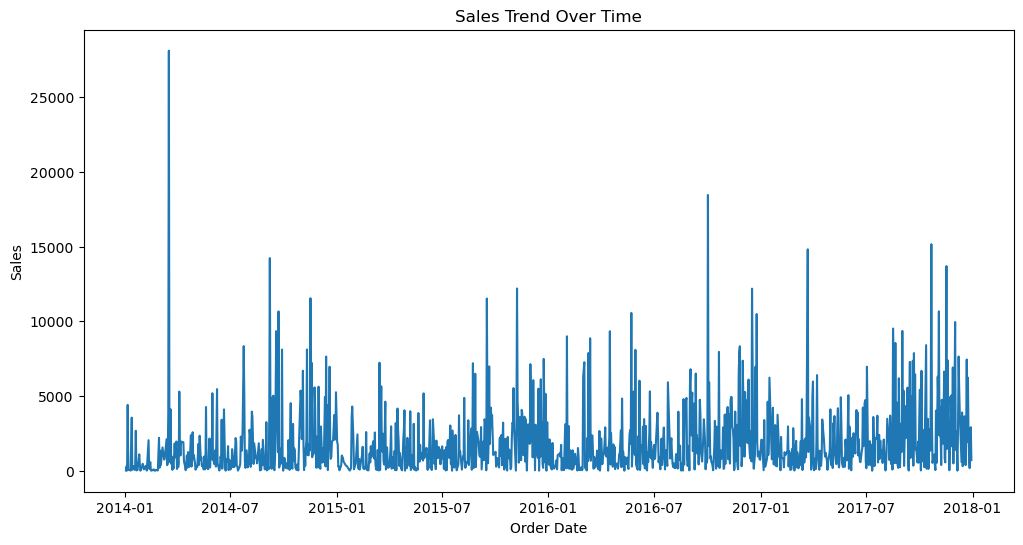

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(sales_data['Order Date'], sales_data['Sales'])

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.show()

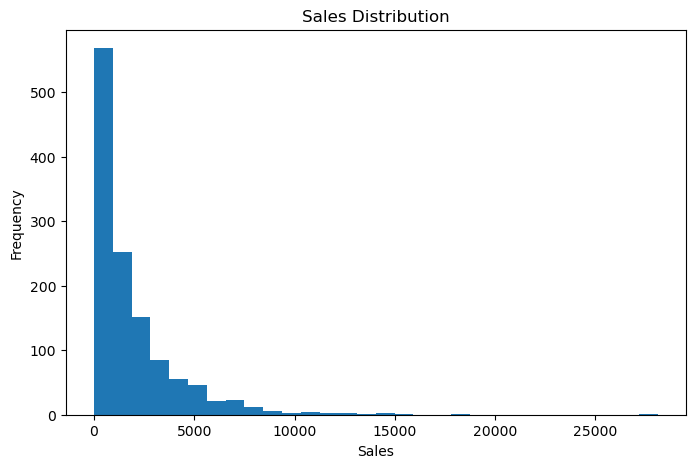

In [37]:
plt.figure(figsize=(8,5))
plt.hist(sales_data['Sales'], bins=30)

plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.show()

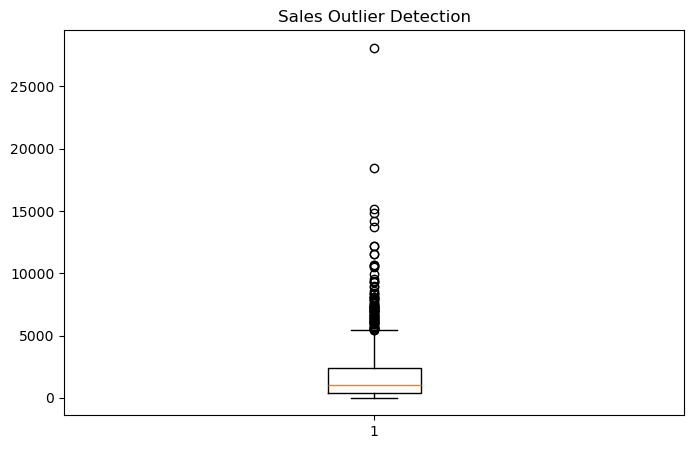

In [38]:
plt.figure(figsize=(8,5))
plt.boxplot(sales_data['Sales'])
plt.title('Sales Outlier Detection')
plt.show()

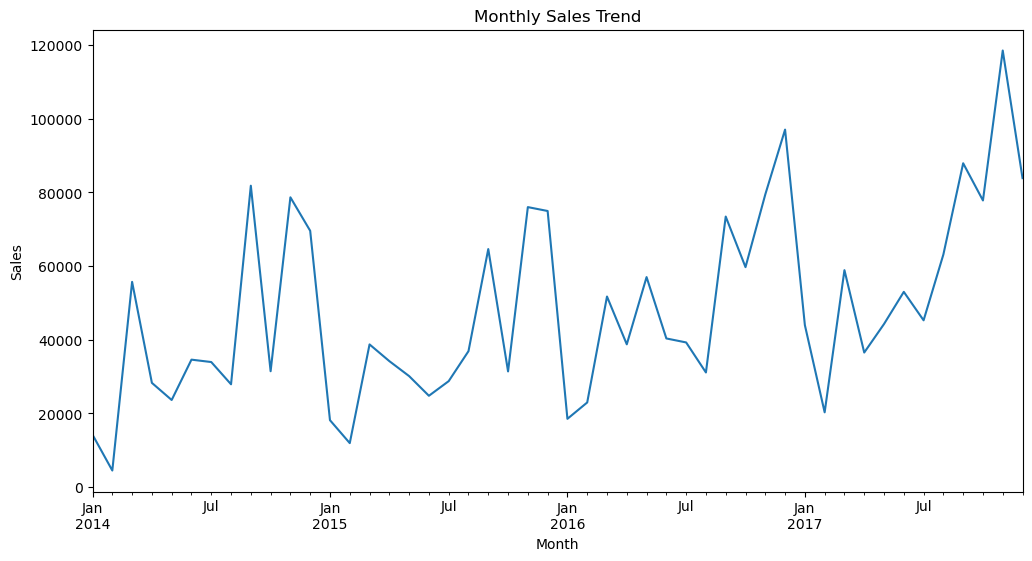

In [39]:
monthly_sales = sales_data.copy()

monthly_sales['Month'] = monthly_sales['Order Date'].dt.to_period('M')

monthly_sales = monthly_sales.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(12,6))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

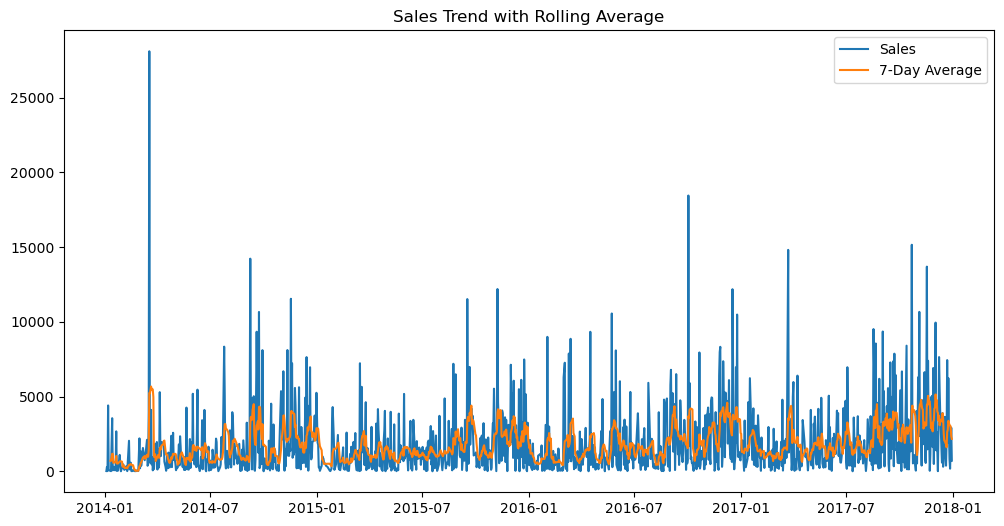

In [40]:
sales_data['Rolling_Avg'] = sales_data['Sales'].rolling(window=7).mean()

plt.figure(figsize=(12,6))

plt.plot(sales_data['Order Date'],
         sales_data['Sales'],
         label='Sales')

plt.plot(sales_data['Order Date'],
         sales_data['Rolling_Avg'],
         label='7-Day Average')

plt.legend()

plt.title('Sales Trend with Rolling Average')

plt.show()

## 9. Feature Engineering

A numerical time-based feature is created to represent the progression of days for model training.

In [28]:
import numpy as np

sales_data['Day_Number'] = np.arange(len(sales_data))

sales_data[['Order Date', 'Day_Number', 'Sales']].head()

,Order Date,Day_Number,Sales
0,2014-01-03,0,16.448
1,2014-01-04,1,288.060
2,2014-01-05,2,19.536
3,2014-01-06,3,4407.100
4,2014-01-07,4,87.158


## 10. Feature Selection

The input feature and target variable are selected for model development.

In [29]:
X = sales_data[['Day_Number']]
y = sales_data['Sales']

X.head()

,Day_Number
0,0
1,1
2,2
3,3
4,4


## 11. Data Splitting

The dataset is divided into training and testing sets to evaluate model performance.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 12. Model Building

Linear Regression is implemented to learn the relationship between time and sales values.

In [48]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully....!")



Model trained successfully....!


## 13. Model Prediction

The trained model is used to generate sales predictions on the test dataset.

In [17]:
sales_data['Predicted_Sales'] = model.predict(X)

sales_data[['Order Date', 'Sales', 'Predicted_Sales']].head()

,Order Date,Sales,Predicted_Sales
0,2014-01-03,16.448,981.770810
1,2014-01-04,288.060,983.128499
2,2014-01-05,19.536,984.486189
3,2014-01-06,4407.100,985.843878
4,2014-01-07,87.158,987.201567


## 14. Model Visualization

Actual and predicted sales values are visualized to assess forecasting performance.

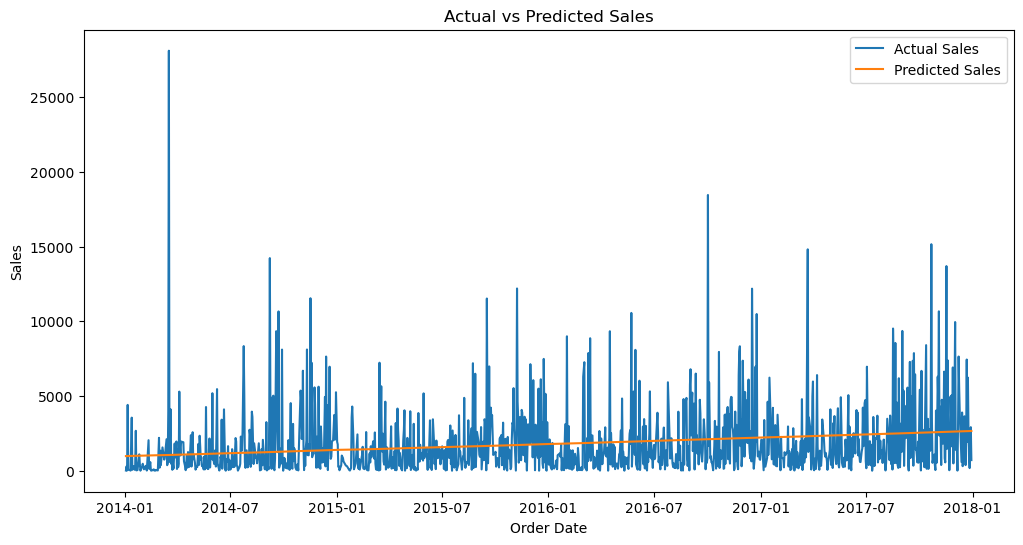

In [18]:
plt.figure(figsize=(12,6))

plt.plot(sales_data['Order Date'], sales_data['Sales'], label="Actual Sales")
plt.plot(sales_data['Order Date'], sales_data['Predicted_Sales'], label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

## 15. Future Sales Forecasting

Future sales values are predicted for the next 30 days using the trained Linear Regression model.

In [42]:
import pandas as pd
import numpy as np
future_days = pd.DataFrame({
    'Day_Number': np.arange(
        sales_data['Day_Number'].max() + 1,
        sales_data['Day_Number'].max() + 31
    )
})

future_predictions = model.predict(future_days)
future_predictions = np.round(future_predictions, 2)


last_date = sales_data['Order Date'].max()


future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30
)


baseline = sales_data['Sales'].iloc[-1]


future_report = pd.DataFrame({
    "Forecast Date": future_dates,
    "Predicted Sales": future_predictions
})


future_report["Forecast %"] = np.round(
    ((future_report["Predicted Sales"] - baseline) / baseline) * 100,
    2
)


future_report["Trend"] = np.where(
    future_report["Forecast %"] >= 0,
    "Increase 📈" ,

    "Decrease 📉"
)

future_report

,Forecast Date,Predicted Sales,Forecast %,Trend
0,2017-12-31,2661.23,272.83,Increase 📈
1,2018-01-01,2662.59,273.02,Increase 📈
2,2018-01-02,2663.95,273.21,Increase 📈
3,2018-01-03,2665.31,273.40,Increase 📈
4,2018-01-04,2666.66,273.59,Increase 📈
5,2018-01-05,2668.02,273.78,Increase 📈
6,2018-01-06,2669.38,273.97,Increase 📈
7,2018-01-07,2670.74,274.16,Increase 📈
8,2018-01-08,2672.09,274.35,Increase 📈
9,2018-01-09,2673.45,274.54,Increase 📈


## 30-Day Sales Forecast Visualization

This visualization represents the predicted sales for the next 30 days generated by the Linear Regression model, providing insights into future sales trends and expected business performance.

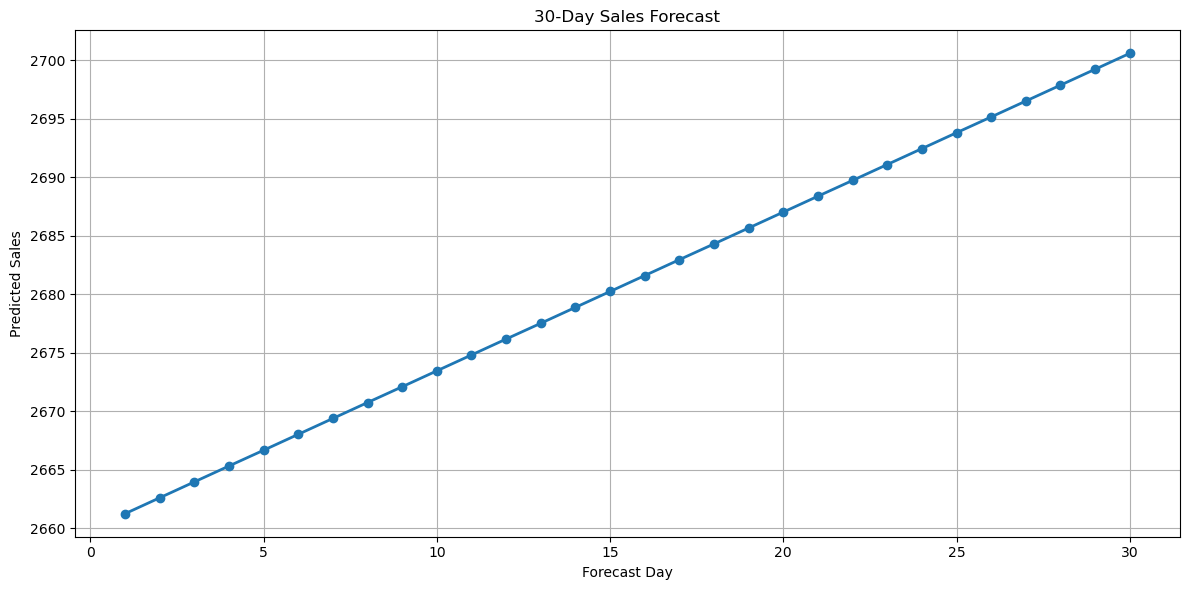

In [47]:
plt.figure(figsize=(12,6))

plt.plot(
    range(1,31),
    future_predictions,
    marker='o',
    linewidth=2
)

plt.title('30-Day Sales Forecast')
plt.xlabel('Forecast Day')
plt.ylabel('Predicted Sales')
plt.grid(True)

plt.tight_layout()
plt.show()

## 16. Model Evaluation

The model is evaluated using performance metrics such as R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

MAE: 1479.0
RMSE: 2596.28
R2 Score: -0.0336


# Conclusion

- The Superstore sales dataset was successfully analyzed and cleaned.
- Missing values and duplicate records were examined during preprocessing.
- Exploratory Data Analysis (EDA) was performed to understand sales trends.
- Linear Regression was implemented for future sales forecasting.
- Future sales predictions were generated and visualized.
- The project demonstrates practical application of data preprocessing, EDA, machine learning, and forecasting concepts.
- Additional features and advanced forecasting models may improve prediction accuracy in future work.